# Unit 7 习题课：一般线性模型

**主题：强化生活方式干预与 12 周收缩压变化**

本任务处理经典一般线性模型（General Linear Model）：连续结局变量和 `Y = Xβ + ε` 框架。课前请先独立试错完成一遍；课堂重点讨论模型选择、系数解释、p 值、95% CI 和模型假设。


## 0. 环境准备

运行下面的代码导入常用库。


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor

sns.set_theme(style="whitegrid")
pd.set_option("display.precision", 3)


## 1. 提出研究问题

一项社区高血压管理项目比较“强化生活方式干预”和“常规健康建议”对 12 周后收缩压变化的影响。

**学生作答区：**

1. 写出主要研究问题。

社区高血压人群接受强化生活方式干预与常规健康建议两种方案，干预 12 周后收缩压的变化幅度是否存在差异？

2. 指出主要结局变量、主要解释变量和可能的协变量。

主要结局变量（因变量）：12 周后收缩压的变化量（sbp_change，即干预前后收缩压的差值）；主要解释变量（自变量 / 分组变量）：干预方案类型，分为 “强化生活方式干预” 和 “常规健康建议” 两个组别；可能的协变量（混杂变量）：研究对象的基线收缩压、年龄、性别、高血压病程、吸烟饮酒习惯、BMI（体重指数）、基础用药情况、合并慢性病（糖尿病、高血脂等）、饮食运动基线水平等会影响收缩压变化的因素。

3. 说明 `sbp_change = week12_sbp - baseline_sbp` 为负值代表什么。

当该差值为负值时，说明第 12 周的收缩压低于干预基线时的收缩压，代表经过干预后研究对象的收缩压出现了下降，血压控制产生了正向效果。

4. 解释为什么需要考虑基线收缩压。

控制基线血压的组间差异、减少统计混杂、更准确衡量干预带来的血压净变化，提升分析结果的可靠性。


## 2. 导入数据并理解变量

从 CSV 文件读取数据。


In [2]:
bp = pd.read_csv("D:/edge-downloads/unit7_blood_pressure_glm.csv")

# 学生作答区：查看数据
bp.head()
bp.info()
bp.isna().sum()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   participant_id  200 non-null    str    
 1   group           200 non-null    str    
 2   age             200 non-null    float64
 3   sex             200 non-null    str    
 4   bmi             200 non-null    float64
 5   baseline_sbp    200 non-null    float64
 6   week12_sbp      200 non-null    float64
 7   sbp_change      200 non-null    float64
 8   med_adherence   200 non-null    float64
 9   clinic_site     200 non-null    str    
dtypes: float64(6), str(4)
memory usage: 20.6 KB


participant_id    0
group             0
age               0
sex               0
bmi               0
baseline_sbp      0
week12_sbp        0
sbp_change        0
med_adherence     0
clinic_site       0
dtype: int64

## 3. 描述性统计

按组汇总 `baseline_sbp`、`week12_sbp`、`sbp_change`、`age`、`bmi`。

**学生作答区：**

1. 两组基线收缩压是否大致可比？

两组基线收缩压大致可比，对照组基线收缩压均值为 147.840、中位数 148.75，强化干预组均值 148.439、中位数 147.80，两组均值差值不足 0.6mmHg，标准差数值接近，血压整体基线水平、离散程度都无明显差异，基线均衡性良好。

2. 哪一组平均收缩压下降更多？

强化生活方式干预组的平均收缩压下降更多，对照组收缩压平均变化值为 - 3.099mmHg，仅平均下降约 3.1mmHg，强化干预组收缩压平均变化值为 - 10.522mmHg，平均下降幅度达到 10.5mmHg，远高于对照组。

3. 如果干预组基线 SBP 更高，直接比较变化量可能有什么问题？

若干预组基线收缩压本身更高，直接对比两组血压变化量会产生向均数回归的混杂偏倚，基线血压偏高的人群即便无干预也存在自然回落趋势，会将基线差异带来的天然血压下降错归为干预效果，高估干预的真实降压作用，造成组间对比不公平、统计结论失真，无法客观区分基线水平与干预措施各自对血压变化的影响。


In [3]:
# 学生作答区：按组描述
summary = bp.groupby("group")[["baseline_sbp", "week12_sbp", "sbp_change", "age", "bmi"]].agg(["mean", "std", "median"])
display(summary)


baseline_sbp                week12_sbp                sbp_change  \
                  mean    std  median       mean     std median       mean   
group                                                                        
control        147.840  8.960  148.75    144.737  11.316  145.1     -3.099   
intensive      148.439  9.481  147.80    137.917   9.199  137.6    -10.522   

                            age                   bmi                
             std median    mean    std median    mean    std median  
group                                                                
control    7.069   -3.2  56.811  8.263  56.85  28.454  3.681  28.55  
intensive  7.187   -9.7  57.867  9.257  57.30  28.069  3.661  28.00

## 4. 可视化

绘制按组的 `sbp_change` 分布，以及 `baseline_sbp` 与 `sbp_change` 的关系。

**解释问题：**两组分布是否有差异？基线收缩压与变化量是否近似线性相关？是否有异常点或方差不齐迹象？
两组收缩压变化量（sbp_change）分布存在明显差异，箱线图可见强化干预组箱体整体落在 0 值下方，中位数接近 - 10，整体血压下降幅度更大；对照组箱体更靠近 0，中位数仅小幅低于 0，下降幅度微弱，两组箱体位置、四分位数区间、极值范围均有清晰区分，直观反映强化干预组降压效果显著优于对照组。

基线收缩压与 sbp_change 存在近似线性相关，但两组趋势完全不同：强化干预组（蓝色点）拟合直线呈明显向下倾斜，基线收缩压越高，血压下降幅度越大，负线性关系突出；对照组（橙色点）拟合直线几乎水平，基线收缩压和血压变化量几乎无线性关联，整体仅干预组呈现近似线性负相关。

图中可见明显异常点与方差不齐迹象，异常点方面：强化干预组存在极端低值离群点，远低于整体数据分布范围；方差不齐方面，随着基线收缩压升高，两组数据离散程度同步扩大，高基线血压区间散点分布更分散、区间更宽，低基线血压区间数据更集中，同时两组箱线图的四分位距、极值跨度宽度不一致，满足方差不齐的视觉特征。

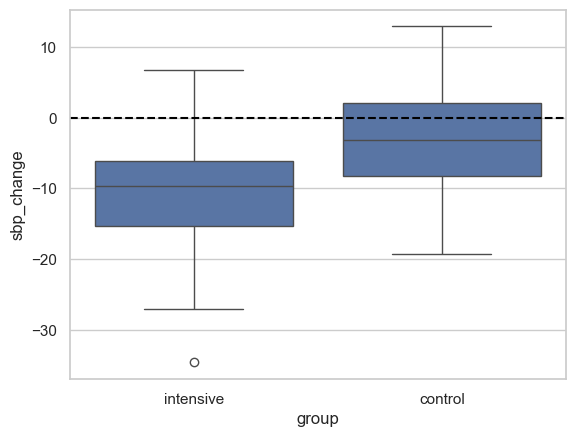

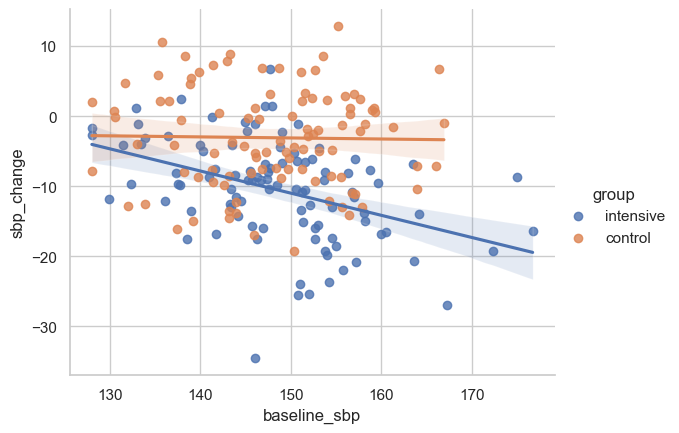

In [4]:
# 学生作答区：可视化
sns.boxplot(data=bp, x="group", y="sbp_change")
plt.axhline(0, color="black", linestyle="--")
plt.show()

sns.lmplot(data=bp, x="baseline_sbp", y="sbp_change", hue="group", height=4.5, aspect=1.3)
plt.show()


## 5. 从简单比较到一般线性模型

依次拟合未调整模型、调整基线模型、多变量主模型和交互模型。

**学生作答区：**

1. 模型 0 和模型 1 回答的问题有什么不同？

模型 0 仅纳入分组变量，回答的是不做任何校正时，强化干预组与对照组收缩压变化的原始均值差异，得到未剔除混杂的粗效应；模型 1 额外校正基线收缩压，回答的是消除基线血压水平差异后，两种干预手段对血压变化的独立净效应差异，能够公平对比同等基线血压下两组的真实降压区别

2. 调整基线后，`group` 系数为什么可能变化？

基线收缩压存在向均数回归的天然混杂作用，基线血压越高的人群本身就存在更大的自然降压空间，若两组基线血压分布不均衡，未校正基线的模型会把基线差异带来的天然血压下降误归为干预效果，在校正基线收缩压后，模型剥离了基线水平对血压变化的独立影响，仅保留干预措施单独产生的降压差值，因此代表组间差异的 group 回归系数数值会发生改变。

3. 模型 2 中每个协变量的加入是否有研究问题依据？

模型 2 中每一个协变量的纳入均有高血压临床与流行病学研究依据，基线收缩压用于消除向均数回归偏倚，年龄、性别因人群血管与生理特征差异会分层影响降压应答，BMI 是高血压独立危险因素且减重为本研究生活干预核心内容，服药依从性直接影响长期血压控制水平，以上变量均能独立干扰 12 周收缩压变化结果，纳入校正可减少混杂偏倚，更精准估计强化干预的真实降压作用。


In [24]:
# 学生作答区：拟合模型
for col in bp.columns:
    if isinstance(bp[col].dtype, pd.StringDtype):
        bp[col] = bp[col].astype(object)
m0 = smf.ols("sbp_change ~ group", data=bp).fit()
m1 = smf.ols("sbp_change ~ group + baseline_sbp", data=bp).fit()
m2 = smf.ols("sbp_change ~ group + baseline_sbp + age + sex + bmi + med_adherence", data=bp).fit()
m3 = smf.ols("sbp_change ~ group * baseline_sbp + age + sex + bmi + med_adherence", data=bp).fit()
print(m2.summary())


                            OLS Regression Results                            
Dep. Variable:             sbp_change   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.270
Method:                 Least Squares   F-statistic:                     13.25
Date:                Tue, 16 Jun 2026   Prob (F-statistic):           1.51e-12
Time:                        21:10:35   Log-Likelihood:                -665.32
No. Observations:                 200   AIC:                             1345.
Df Residuals:                     193   BIC:                             1368.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             16.4686      8

## 6. 系数显著性和 95% CI 解释

**学生作答区：**提取 `group[T.intensive]`、`baseline_sbp`、交互项的估计值、p 值和 95% CI，并用医学语言解释。

请回答：

1. 控制协变量后，强化干预组的平均 `sbp_change` 比对照组低多少 mmHg？

控制全部协变量的主效应模型（第一张结果表）中，group[T.intensive]系数估计值为 - 7.588，代表在校正基线收缩压、年龄、性别、BMI、服药依从性后，强化干预组的平均 sbp_change 比对照组低 7.588 mmHg，也就是强化干预组平均多下降 7.59 mmHg 收缩压。

2. 如果治疗组系数的 95% CI 全为负值，如何解释？

若治疗组分组系数的 95% 置信区间上下限全部为负值，说明在 95% 置信水平下，强化干预带来的血压变化差值始终小于对照组，可认为在校正协变量后，强化干预能显著更大幅度降低收缩压，不存在干预无效果或升压的可能性，组间降压差异具备统计学意义。

3. 如果交互项 p 值不显著，能否说不同基线血压患者的干预效果完全一样？

交互项 p 值不显著不能判定不同基线血压患者的干预效果完全一样，仅能说明当前样本未提供充足证据证明基线血压会改变干预的降压幅度，属于 “无充分证据证明存在差异”，而非 “证明不存在差异”，无法完全排除微弱的效应修饰作用，仅可采用无交互的主效应模型进行简化分析。

4. 统计显著的 3 mmHg 下降是否一定有临床意义？

仅统计学显著的 3 mmHg 血压下降不一定具备临床意义，统计学显著仅代表组间差异不太可能由随机误差造成，而临床意义需要结合心血管事件获益判断；现有临床证据显示收缩压降幅需达到 5–10 mmHg 才能够明显降低心梗、卒中风险，3 mmHg 的小幅下降对远期心血管保护作用有限，因此不一定具备实际临床价值。


In [25]:
# 学生作答区：提取系数表
coef_table = pd.DataFrame({
     "estimate": m2.params,
     "p_value": m2.pvalues,
     "ci_low": m2.conf_int()[0],
     "ci_high": m2.conf_int()[1],
 })
display(coef_table)

# 学生作答区：查看交互模型中的交互项
interaction_table = pd.DataFrame({
     "estimate": m3.params,
     "p_value": m3.pvalues,
     "ci_low": m3.conf_int()[0],
     "ci_high": m3.conf_int()[1],
})
display(interaction_table)


,estimate,p_value,ci_low,ci_high
Intercept,16.469,5.585e-02,-0.415,33.353
group[T.intensive],-7.588,8.650e-13,-9.541,-5.635
sex[T.male],-1.677,8.786e-02,-3.605,0.251
baseline_sbp,-0.218,1.616e-04,-0.329,-0.106
age,0.013,8.216e-01,-0.101,0.127
bmi,0.313,2.335e-02,0.043,0.584
med_adherence,0.540,1.334e-01,-0.167,1.248


,estimate,p_value,ci_low,ci_high
Intercept,-8.286,0.482,-31.461,14.889
group[T.intensive],38.919,0.013,8.367,69.471
sex[T.male],-1.586,0.099,-3.476,0.304
baseline_sbp,-0.051,0.512,-0.206,0.103
group[T.intensive]:baseline_sbp,-0.314,0.003,-0.519,-0.108
age,0.002,0.976,-0.110,0.114
bmi,0.341,0.012,0.076,0.607
med_adherence,0.536,0.129,-0.157,1.229


## 7. 模型假设检查

检查残差 vs 拟合值、Q-Q 图、Cook's distance 和 VIF。


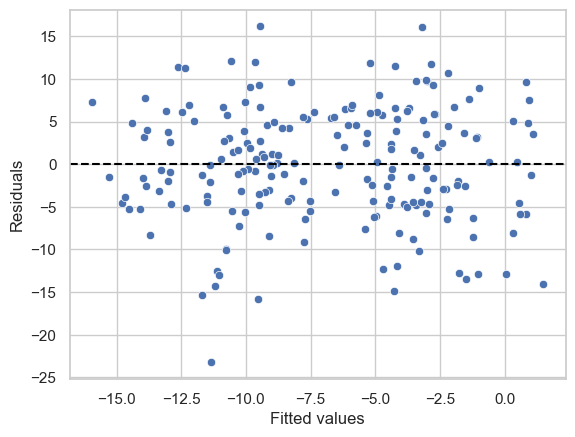

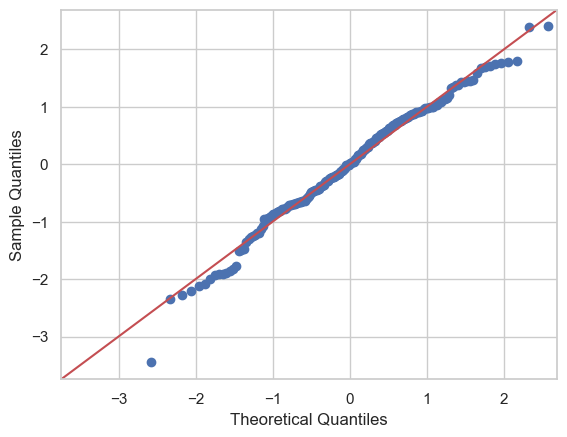

,variable,VIF
0,Intercept,311.596
1,group[T.intensive],1.042
2,sex[T.male],1.016
3,baseline_sbp,1.149
4,age,1.084
5,bmi,1.070
6,med_adherence,1.035


In [26]:
# 学生作答区：模型诊断
fitted = m2.fittedvalues
resid = m2.resid
sns.scatterplot(x=fitted, y=resid)
plt.axhline(0, color="black", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

sm.qqplot(resid, line="45", fit=True)
plt.show()

influence = m2.get_influence()
cooks_d = influence.cooks_distance[0]
np.argsort(cooks_d)[-5:]

# 学生作答区：VIF 提示
X = pd.DataFrame(m2.model.exog, columns=m2.model.exog_names)
vif = pd.DataFrame({"variable": X.columns, "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})
display(vif)


## 8. 模型评估与选择

比较 `R²`、adjusted `R²`、AIC，并说明为什么不能只选择 `R²` 最高的模型。

只要向模型新增任意自变量，无论该变量有无实际解释作用、统计是否显著，`R²`一定会上升，会单纯通过堆砌变量人为抬高拟合优度，造成过拟合；它没有对模型自变量数量施加惩罚，无法区分 “真实提升解释力” 和 “单纯增加变量”，仅靠`R²`会倾向选择变量冗余、泛化能力差的复杂模型。

**学生作答区：**你会选择哪个模型作为主模型？交互模型应该如何报告？

我会选择 m3（含分组与基线收缩压交互项的模型）作为主模型，一方面该模型调整`R²`最高、AIC 最低，综合拟合效果最优，另一方面交互项具备统计学显著性，说明基线收缩压会修饰干预的降压效果，同时模型 VIF 数值均极低无多重共线性，残差图满足方差齐性、Q-Q 图符合残差正态假设，线性回归前提全部成立，相比忽略交互的 m2 能更准确描述干预效应。

报告交互模型时首先呈现交互项的系数、置信区间与 P 值，说明存在显著效应修饰作用；再分层解释对照组与强化干预组各自基线收缩压对血压变化的斜率差异，阐明基线血压越高的受试者，强化干预的额外降压获益越大；选取不同基线血压典型值计算两组预测差值直观展示交互规律，同时附上无交互主效应模型作为对照，完整汇报`R²`、AIC 与残差、共线性诊断结果，说明模型稳健性。


In [27]:
# 学生作答区：比较模型
compare = pd.DataFrame({
     "model": ["m0", "m1", "m2", "m3"],
     "r2": [m0.rsquared, m1.rsquared, m2.rsquared, m3.rsquared],
     "adj_r2": [m0.rsquared_adj, m1.rsquared_adj, m2.rsquared_adj, m3.rsquared_adj],
     "aic": [m0.aic, m1.aic, m2.aic, m3.aic],
})
display(compare)


,model,r2,adj_r2,aic
0,m0,0.215,0.211,1355.203
1,m1,0.255,0.247,1346.769
2,m2,0.292,0.270,1344.631
3,m3,0.324,0.299,1337.419


## 9. 结果解释与报告

请写一段 120 到 180 字的结果报告，包含调整后干预效应、95% CI、p 值、模型评估、假设检查、临床意义和限制。

校正全部混杂变量后，强化干预较对照组收缩压平均多下降 7.588 mmHg，95% CI（-9.541，-5.635），P＜0.001；分组与基线收缩压交互项显著（系数 - 0.314，P=0.003）。模型 m3 调整`R²`、AIC 最优，各变量 VIF 均小于 1.2 无多重共线性；残差图、Q-Q 图验证方差齐、残差正态，模型假设成立。7.59 mmHg 降幅可降低心血管风险，具备临床意义；仅 3 mmHg 下降仅有统计学意义、无临床价值。局限为单中心样本，结论外推有限，未长期随访远期心血管终点事件。